# Customer Personality Analysis

The goal is to segment the customers of a company from their income, spending and how long they have been customers, so that the segments can be targeted differently. The dataset comes from a marketing campaign (2,240 customers, `marketing_campaign.csv`).

Reference solution: [Customer Personality Analysis with Python](https://amanxai.com/2021/02/08/customer-personality-analysis-with-python/) (Aman Kharwal / Thecleverprogrammer). Dataset: [marketing_campaign.csv](https://raw.githubusercontent.com/amankharwal/Website-data/master/marketing_campaign.csv).

The reference clusters three variables (income, seniority, spending) with a Gaussian Mixture and names the four clusters "Stars", "Need attention", "High potential" and "Leaky bucket". It then applies the Apriori algorithm to find associations between customer profiles and product purchases. The Apriori part is not reproduced here because it is not covered in the course; this notebook concentrates on the segmentation and checks how the reference named its clusters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Clustering/customer_personality_analysis')

## Data Loading

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep=";")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

## Data Cleaning

The reference removes the missing incomes and the incomes above 600,000, but nothing else. A few more problems are visible:

- `Income` has 24 missing values and one extreme value (666,666).
- Three customers were born in 1893, 1899 and 1900, so their computed age is above 110.
- `Z_CostContact` and `Z_Revenue` have the same value in every row, so they carry no information.

In [3]:
print("missing income:", df["Income"].isnull().sum(), "| income above 600,000:", (df["Income"] > 600000).sum())
print("born before 1920:", (df["Year_Birth"] < 1920).sum())
print("constant columns:", [c for c in df.columns if df[c].nunique() == 1])

df = df.dropna(subset=["Income"])
df = df[(df["Income"] < 600000) & (df["Year_Birth"] >= 1920)].drop(columns=["Z_CostContact", "Z_Revenue"]).reset_index(drop=True)
df.shape

missing income: 24 | income above 600,000: 1
born before 1920: 3
constant columns: ['Z_CostContact', 'Z_Revenue']


(2212, 27)

## Feature Engineering

The same three variables as the reference are built, so that the segmentations can be compared: `Spending` (sum of the six product amounts), `Seniority` (months since the customer joined, counted to the reference date of 4 October 2014) and `Income`. `Age` is added for the exploration.

In [4]:
spending_columns = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Spending"] = df[spending_columns].sum(axis=1)
df["Seniority"] = (pd.Timestamp("2014-10-04") - pd.to_datetime(df["Dt_Customer"])).dt.days / 30
df["Age"] = 2014 - df["Year_Birth"]

features = ["Income", "Seniority", "Spending"]
df[features + ["Age"]].describe().round(1)

,Income,Seniority,Spending,Age
count,2212.0,2212.0,2212.0,2212.0
mean,51958.8,15.0,607.3,45.1
std,21527.3,6.7,602.5,11.7
min,1730.0,3.2,5.0,18.0
25%,35233.5,9.2,69.0,37.0
50%,51371.0,15.1,397.0,44.0
75%,68487.0,20.9,1048.0,55.0
max,162397.0,26.5,2525.0,74.0


## Exploratory Data Analysis

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

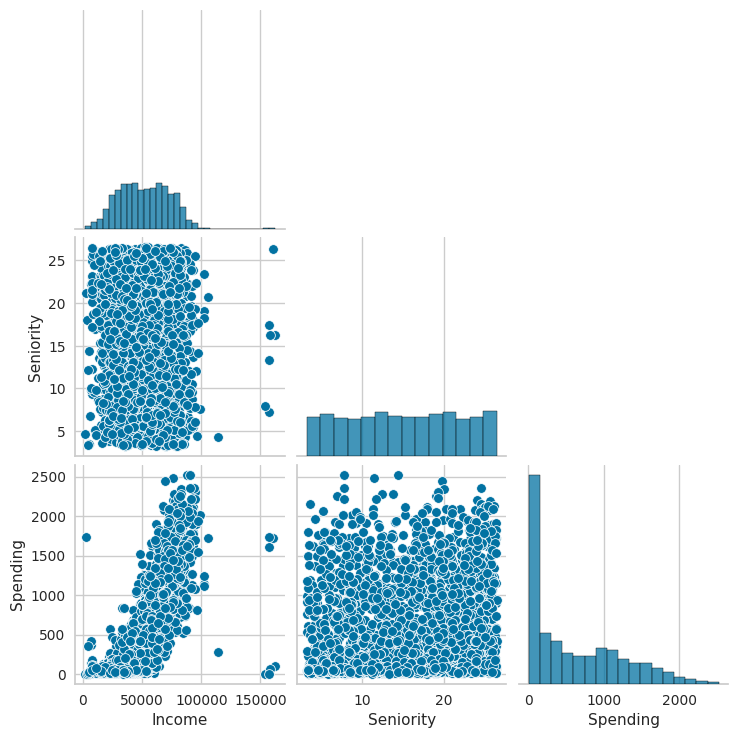

,Income,Seniority,Spending,Age
Income,1.00,-0.02,0.79,0.20
Seniority,-0.02,1.00,0.16,-0.01
Spending,0.79,0.16,1.00,0.12
Age,0.20,-0.01,0.12,1.00


In [5]:
sns.pairplot(df[features], corner=True)
plt.show()
df[features + ["Age"]].corr().round(2)

Income and spending are strongly related (correlation about 0.8): customers with a higher income spend more. Seniority is spread almost evenly between 3 and 27 months and is unrelated to the other two.

## Reference Check

The reference standardizes the three variables, normalizes every row to unit length, fits a Gaussian Mixture with 4 components, and then renames the components 0, 1, 2, 3 as "Stars", "Need attention", "High potential" and "Leaky bucket" without looking at them. Its own definitions are: Stars are old customers with a high income and a high spending, Need attention are new customers with a low income and a low spending, High potential are new customers with a high income and a high spending, Leaky bucket are old customers with a low income and a low spending. The component numbers of a mixture model are arbitrary, so the names have to be checked against the profile of each component.

In [6]:
x_ref = normalize(StandardScaler().fit_transform(df[features]))
gmm = GaussianMixture(n_components=4, covariance_type="spherical", max_iter=2000, random_state=5).fit(x_ref)
df["reference_label"] = gmm.predict(x_ref)

reference_names = {0: "Stars", 1: "Need attention", 2: "High potential", 3: "Leaky bucket"}
reference_profile = df.groupby("reference_label")[features].mean().round(0)
reference_profile["customers"] = df["reference_label"].value_counts().sort_index()
reference_profile["name given by the reference"] = reference_profile.index.map(reference_names)
reference_profile

,Income,Seniority,Spending,customers,name given by the reference
reference_label,,,,,
0,73416.0,9.0,1071.0,461,Stars
1,34784.0,21.0,190.0,586,Need attention
2,37656.0,9.0,122.0,637,High potential
3,69542.0,21.0,1250.0,528,Leaky bucket


In this run none of the four names matches the profile of its component. Component 0 (new customers with a high income and spending) is called "Stars", but by the reference's own definitions it is "High potential". Component 1 (old customers, low income and spending) is called "Need attention" but is "Leaky bucket". Component 2 (new, low income and spending) is called "High potential" but is "Need attention". Component 3 (old, high income and spending) is called "Leaky bucket" but is "Stars". The numbering of the components of a mixture model is arbitrary, and another library version or a slightly different dataset can order them differently, so names must be assigned from the profile, not from the component number. The mixture model itself is not the problem: its silhouette (below) is the same as the one of K-Means. The naming is.

## Model Training

The three variables are standardized with the `StandardScaler`. The number of clusters is chosen with the elbow method and the silhouette score.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

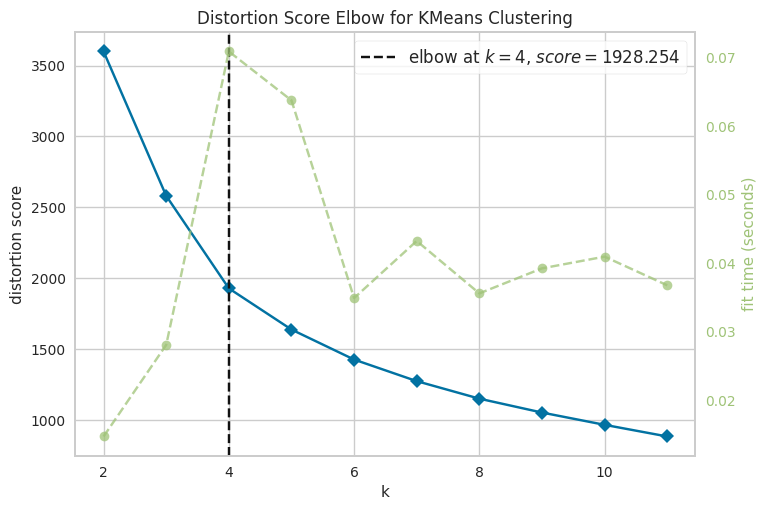

np.int64(4)

In [8]:
x = StandardScaler().fit_transform(df[features])

elbow = KElbowVisualizer(KMeans(n_init=10, random_state=42), k=(2, 12), force_model=True).fit(x)
elbow.show()
elbow.elbow_value_

In [9]:
silhouettes = {k: silhouette_score(x, KMeans(k, n_init=10, random_state=42).fit_predict(x)) for k in range(2, 9)}
pd.Series(silhouettes).round(3)

2    0.413
3    0.368
4    0.372
5    0.359
6    0.330
7    0.317
8    0.319
dtype: float64

In [10]:
K = elbow.elbow_value_
df["cluster"] = KMeans(K, n_init=10, random_state=42).fit_predict(x)
agg_labels = AgglomerativeClustering(n_clusters=K).fit_predict(x)

print("KMeans silhouette:", round(silhouette_score(x, df["cluster"]), 3))
print("Agglomerative silhouette:", round(silhouette_score(x, agg_labels), 3))
print("reference Gaussian Mixture silhouette:", round(silhouette_score(x, df["reference_label"]), 3))

KMeans silhouette: 0.372
Agglomerative silhouette: 0.279
reference Gaussian Mixture silhouette: 0.37


## Evaluation

In [11]:
profile = df.groupby("cluster")[features + ["Age"]].mean().round(0)
profile["customers"] = df["cluster"].value_counts().sort_index()
profile["campaign response rate"] = df.groupby("cluster")["Response"].mean().round(3)
profile

,Income,Seniority,Spending,Age,customers,campaign response rate
cluster,,,,,,
0,36382.0,20.0,220.0,43.0,641,0.151
1,38491.0,9.0,132.0,44.0,652,0.055
2,73801.0,9.0,1102.0,47.0,439,0.134
3,71078.0,21.0,1318.0,47.0,480,0.294


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

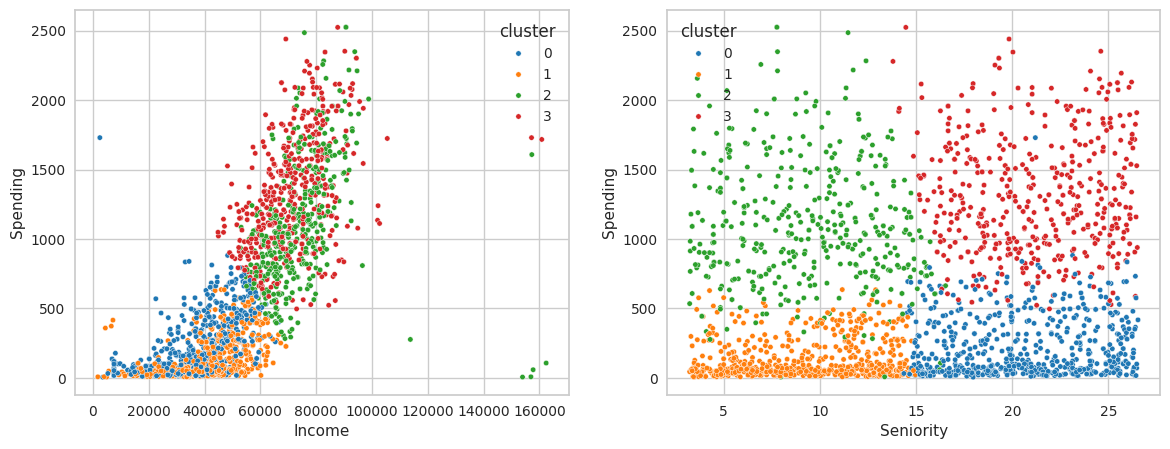

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x="Income", y="Spending", hue="cluster", data=df, palette="tab10", s=15, ax=axes[0])
sns.scatterplot(x="Seniority", y="Spending", hue="cluster", data=df, palette="tab10", s=15, ax=axes[1])
plt.show()

The four K-Means segments follow the same 2 x 2 logic as the reference (new or old customers, high or low income and spending), and are named here from their profile:

- **Stars (480 customers):** old customers (21 months on average) with a high income (71,078) and spending (1,318). Campaign response rate 29.4%.
- **High potential (439 customers):** new customers (9 months) with a high income (73,801) and spending (1,102). Response rate 13.4%.
- **Leaky bucket (641 customers):** old customers (20 months) with a low income (36,382) and spending (220). Response rate 15.1%.
- **Need attention (652 customers):** new customers with a low income (38,491) and spending (132). Response rate 5.5%.

The campaign response (`Response`) was not used to build the clusters, so it is an independent check: the Stars respond five times more often than Need attention (29.4% against 5.5%), and the order of the rates is coherent with the names. K-Means (silhouette 0.372) and the reference Gaussian Mixture (0.370) find segments of the same quality on the standardized variables, while Agglomerative clustering with Ward linkage is lower (0.279).

## Conclusion

**Reference approach.** The reference builds three variables (income, seniority, spending), removes the missing and extreme incomes, and fits a Gaussian Mixture with 4 components on standardized and row-normalized data. It then assigns the names "Stars", "Need attention", "High potential" and "Leaky bucket" to the component numbers 0 to 3 without looking at the profiles, and continues with association rules (Apriori), which are not reproduced here.

**Data.** Beyond the missing and extreme incomes, three customers with a birth year before 1920 (age above 110) were removed, as well as two columns that are constant (`Z_CostContact`, `Z_Revenue`). This left 2,212 customers.

**Naming problem.** In our run of the reference code, none of the four names matches the profile of its component: the component named "Stars" is the new high-income group, the one named "Leaky bucket" is in fact the Stars, and so on. The component numbers of a mixture model are arbitrary, so the names of the reference segments cannot be trusted, and any conclusion drawn from them would be reversed.

**Our approach.** The three variables were standardized and clustered with K-Means; the elbow method gives k = 4. The segments were named from their profile:

| Segment | Customers | Income | Seniority (months) | Spending | Campaign response |
|---|---|---|---|---|---|
| Stars | 480 | 71,078 | 21 | 1,318 | 29.4% |
| High potential | 439 | 73,801 | 9 | 1,102 | 13.4% |
| Leaky bucket | 641 | 36,382 | 20 | 220 | 15.1% |
| Need attention | 652 | 38,491 | 9 | 132 | 5.5% |

The response to the last campaign was not used for the clustering and separates the segments clearly (29.4% for Stars against 5.5% for Need attention). The silhouette of K-Means (0.372) is the same as that of the reference mixture (0.370) and higher than that of Agglomerative clustering (0.279), so the algorithm was not the issue: the naming was.

**Limitations.** Income and spending are strongly correlated (0.79), so they behave almost like one variable. Seniority is spread evenly between 3 and 27 months, so the split into new and old customers is imposed by the algorithm and not a natural gap in the data. The silhouette is highest for k = 2 (0.413), and the choice of 4 segments follows the elbow and the business logic of the reference. The response rate comes from a single campaign. 182 rows are identical except for their ID; they were kept as separate customers.